**<font color = black size=6>实验五：支持向量机</font>**

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import cvxopt
from cvxopt import matrix
from cvxopt import solvers

**<font color = blue size=4>第一部分:函数介绍</font>**

二次规划问题是形式如下的一类最优化问题：
$$
\begin{align}
\min_x \quad  &\frac{1}{2}x^TPx+q^Tx \\
s.t. \quad  &Gx\leq h \\
      &Ax=b
\end{align}
$$
对于这一类问题可以使用[cvxopt](https://cvxopt.org/userguide/coneprog.html#quadratic-programming)库的solvers.qp()函数进行求解。

以下是一个例子（参考[Solving a quadratic program](https://cvxopt.org/examples/tutorial/qp.html)）:
$$
\begin{align}
\min_x \quad  &2x_1^2+x_2^2+x_1x_2+x_1+x_2 \\
s.t. \quad  &x_1\geq 0 \\
      &x_2\geq 0 \\
      &x_1+x_2=1
\end{align}
$$
为了使用solvers.qp()函数，我们需要知道在该二次规划问题中的$P,q,G,h,A,b$矩阵分别是什么。
在该优化问题中，

* $P:=\begin{bmatrix}
    4 & 1 \\ 1 & 2
   \end{bmatrix}$,
* $q:=\begin{bmatrix}
    1 \\ 1
   \end{bmatrix}$,
* $G:=\begin{bmatrix}
    -1 & 0 \\ 0 & -1
   \end{bmatrix}$,
* $h:=\begin{bmatrix}
    0 \\ 0
   \end{bmatrix}$,
* $A:=\begin{bmatrix}
    1 & 1
   \end{bmatrix}$,
* $b:=\begin{bmatrix}
    1
   \end{bmatrix}$,
   
把这些参数送入solvers.qp()函数中即可求出解。

In [179]:
# Tips1: cvxopt库中的matrix只接受double类型的数据
# Tips2: matrix使用列表作为参数创建矩阵和numpy.array使用列表作为参数创建矩阵是不同的
# print(matrix([[1.0, 1.0]]))
# print(np.array([[1.0, 1.0]]))
# print(matrix(np.array([[1.0, 1.0]])))
Q = 2*matrix([ [2, .5], [.5, 1] ])
p = matrix([1.0,1.0])
G = matrix([[-1.0,0.0],[0.0,-1.0]])
h = matrix([0.0,0.0])
A = matrix([1.0, 1.0], (1,2))
b = matrix(1.0)
sol=solvers.qp(Q, p, G, h, A, b)
print(sol['x'])

     pcost       dcost       gap    pres   dres
 0:  1.8889e+00  7.7778e-01  1e+00  2e-16  2e+00
 1:  1.8769e+00  1.8320e+00  4e-02  1e-16  6e-02
 2:  1.8750e+00  1.8739e+00  1e-03  1e-16  5e-04
 3:  1.8750e+00  1.8750e+00  1e-05  0e+00  5e-06
 4:  1.8750e+00  1.8750e+00  1e-07  2e-16  5e-08
Optimal solution found.
[ 2.50e-01]
[ 7.50e-01]



**<font color = blue size=4>第二部分:实验任务</font>**

1.线性可分支持向量机与硬间隔最大化

<span style="color:purple">1) 读入数据集'dataset1.csv',把数据类型都转换成np.double类型，并画出数据集的散点图，给正样本（y为+1）和负样本（y为-1）分别标上不同的颜色。</span>

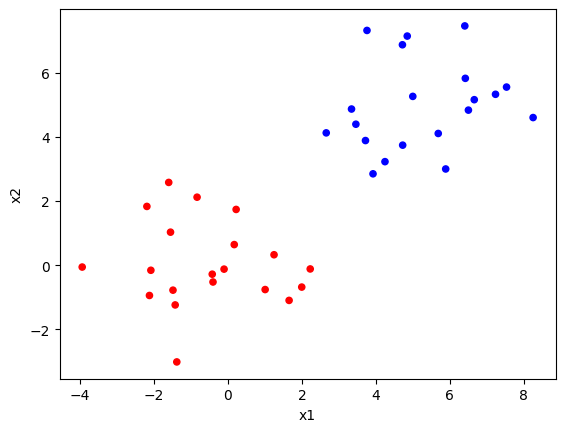

In [180]:
# ---- Your code here ----
file = pd.read_csv('dataset1.csv')
df = pd.DataFrame(file)
data = np.array(df, dtype=np.double)
y = data[:, -1]
X = data[:, :-1]
import matplotlib.pyplot as plt
df.plot.scatter(x='x1', y='x2', c=df['y'].apply(lambda y: 'red' if y == -1 else 'blue'))
plt.show()

<span style="color:purple">2) 求解如下对偶问题（参考课件）：</span>
$$
\begin{align}
\min_\alpha \quad  &\frac{1}{2}\sum_{i=1}^m\sum_{j=1}^m\alpha_i\alpha_jy_iy_j\pmb{x}_i^T\pmb{x}_j-\sum_{i=1}^m\alpha_i \\
s.t. \quad  &\sum_{i=1}^m\alpha_iy_i=0 \\
      &\pmb{\alpha}\geq \pmb{0}
\end{align}
$$

这个优化问题是一个二次规划问题。
* $P是一个m\times m的矩阵，其中P_{ij}=y_iy_j\pmb{x}_i^T\pmb{x}_j$,
* $q是一个m\times 1的所有值都为-1的列向量，即q:=\begin{bmatrix}
    -1 & -1 & \cdots & -1
   \end{bmatrix}^T$,
* $G:=\begin{bmatrix}
    -1 & 0 & \cdots & 0 \\
    0 & -1 & \cdots & 0 \\
   \vdots & \vdots & \ddots &0 \\
   0 & 0 & 0 & -1
   \end{bmatrix}_{m\times m}=-\pmb{I},\pmb{I}为单位矩阵,$
* $h是一个m\times 1的零向量,即h:=\begin{bmatrix}
    0 & 0 & \cdots & 0
   \end{bmatrix}^T$,
* $A:=\begin{bmatrix}
    y_1 & y_2 & \cdots & y_m
   \end{bmatrix}^T$,
* $b:=\begin{bmatrix}
    0
   \end{bmatrix},一个标量$
   
<span style="color:purple">把上述参数送入求解器solvers.qp()中即可得到最优解$\alpha^*$</span>。 
 
附：$P$矩阵的一个计算方法：
设$X=\begin{bmatrix}
    x_{11} & x_{12} \\
    x_{21} & x_{22} \\
    \vdots & \vdots \\
    x_{m1} & x_{m2}
   \end{bmatrix}$,
   $Y=\begin{bmatrix}
    y_{1} \\
    y_{2} \\
    \vdots \\
    y_{m}
   \end{bmatrix}$,
   
计算$X'=\begin{bmatrix}
    x_{11}y_1 & x_{12}y_1 \\
    x_{21}y_2 & x_{22}y_2 \\
    \vdots & \vdots \\
    x_{m1}y_m & x_{m2}y_m
   \end{bmatrix}=X*Y(注意这里是星乘)$
   
则$P=X'X'^T$。

In [181]:
# ---- Your code here ----
#如果求解报错可以尝试在solvers.qp()中添加参数kktsolver='ldl'
P = (X * y.reshape(-1, 1)) @ (X * y.reshape(-1, 1)).T
q = -np.ones(len(y))
G = -np.eye(len(y))
h = np.zeros(len(y))
A = y.reshape(1, -1)
b = np.array([0.0])
sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h), matrix(A), matrix(b))
alphas = np.array(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -5.2553e+00 -9.0147e+00  1e+02  1e+01  2e+00
 1: -4.9265e+00 -1.9551e+00  2e+01  2e+00  3e-01
 2: -1.5759e-01 -3.1831e-01  7e-01  4e-02  7e-03
 3: -1.3147e-01 -1.9706e-01  7e-02  6e-17  1e-15
 4: -1.7378e-01 -1.8099e-01  7e-03  4e-17  8e-16
 5: -1.7979e-01 -1.8010e-01  3e-04  8e-17  1e-15
 6: -1.8003e-01 -1.8003e-01  3e-06  3e-17  1e-15
 7: -1.8003e-01 -1.8003e-01  3e-08  3e-17  1e-15
Optimal solution found.


<span style="color:purple">3) 求出$\pmb{\omega}^*=\sum_{i=1}^m\alpha_i^*y_i\pmb{x}_i$和$b^*=y_j-\pmb{\omega}^{*T}\pmb{x_j}$, 其中$j$为$\alpha^*$中的一个正分量$\alpha_j^*>0$的下标。注意：由于求解器求出来的是一个近似解，所以$\alpha^*$中很多实际上为0的分量会略大于0，这时候可以设置一个阈值把非常靠近0的那些分量筛去，再从剩下的分量中选取一个正分量来计算$b^*$,或者也可以直接取$\alpha^*$中最大的分量来计算$b^*$。</span>

In [182]:
# ---- Your code here ----
omega = np.sum(alphas * y.reshape(-1, 1) * X, axis=0)
b = y.reshape(-1, 1) - X @ omega.reshape(-1, 1)
for i in range(len(alphas)):
    if alphas[i] > 1e-5:
        b = b[i][0]
        break
omega, b

(array([0.40821121, 0.43979838]), np.float64(-1.8556818844864766))

<span style="color:purple">4) 画出数据集的散点图，给正样本（y为+1）和负样本（y为-1）分别标上不同的颜色，再为支持向量（训练数据中$\alpha_j^*>0$的对应的样本）标上不同的颜色，并画出决策边界$\pmb{\omega}^{*T}\pmb{x}+b=0$和间隔边界$\pmb{\omega}^{*T}\pmb{x}+b=1$与$\pmb{\omega}^{*T}\pmb{x}+b=-1$。</span>

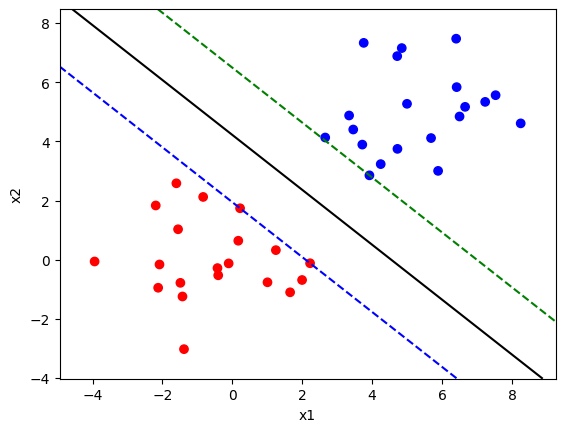

In [183]:
# ---- Your code here ----
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=['red' if label == -1 else 'blue' for label in y])
x1_min, x1_max = X[:, 0].min()-1, X[:, 0].max()+1
x2_min, x2_max = X[:, 1].min()-1, X[:, 1].max()+1
range_X1 = np.linspace(x1_min, x1_max, 100)
range_X2 = np.linspace(x2_min, x2_max, 100)
decision = omega[0] * range_X1.reshape(-1, 1) + omega[1] * range_X2.reshape(1, -1) + b
boundary1 = omega[0] * range_X1.reshape(-1, 1) + omega[1] * range_X2.reshape(1, -1) + b - 1
boundary2 = omega[0] * range_X1.reshape(-1, 1) + omega[1] * range_X2.reshape(1, -1) + b + 1
plt.contour(range_X1, range_X2, boundary1.T, levels=[0], colors='green', linestyles='dashed')
plt.contour(range_X1, range_X2, boundary2.T, levels=[0], colors='blue', linestyles='dashed')
plt.contour(range_X1, range_X2, decision.T, levels=[0], colors='black')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

2.线性支持向量机与软间隔最大化

<span style="color:purple">1) 读入数据集'dataset2.csv',把数据类型都转换成np.double类型，并画出数据集的散点图，给正样本（y为+1）和负样本（y为-1）分别标上不同的颜色。</span>

<Axes: xlabel='x1', ylabel='x2'>

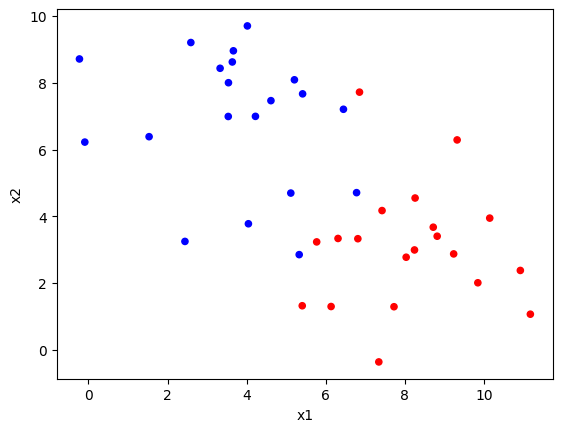

In [185]:
# ---- Your code here ----
file = pd.read_csv("dataset2.csv")
dfe = pd.DataFrame(file)
data = np.array(dfe, dtype=np.double)
X = data[:, :-1]
y = data[:, -1]
dfe.plot.scatter(x='x1', y='x2', c=dfe['y'].apply(lambda y: 'red' if y == -1 else 'blue'))

<span style="color:purple">2) 选择一个参数C，求解如下对偶问题（参考课件）：</span>
$$
\begin{align}
\min_\alpha \quad  &\frac{1}{2}\sum_{i=1}^m\sum_{j=1}^m\alpha_i\alpha_jy_iy_j\pmb{x}_i^T\pmb{x}_j-\sum_{i=1}^m\alpha_i \\
s.t. \quad  &\sum_{i=1}^m\alpha_iy_i=0 \\
      &\pmb{0}\leq \pmb{\alpha}\leq C 
\end{align}
$$
* $G:=\begin{bmatrix}
    -1 & 0 & \cdots & 0 \\
    0 & -1 & \cdots & 0 \\
   \vdots & \vdots & \ddots &0 \\
   0 & 0 & 0 & -1 \\
   1 & 0 & \cdots & 0 \\
    0 & 1 & \cdots & 0 \\
   \vdots & \vdots & \ddots &0 \\
   0 & 0 & 0 & 1
   \end{bmatrix}_{2m\times m}=\begin{bmatrix}
    -\pmb{I} \\
    \pmb{I}
   \end{bmatrix},\pmb{I}为单位矩阵,$
* $h:=\begin{bmatrix}
    0 \\
    0 \\
    \vdots \\
    0 \\
    C \\
    C \\
    \vdots \\
    C
   \end{bmatrix}_{2m\times 1}, 即一个m\times 1的零列向量与一个m\times 1的分量全为C的列向量上下拼接$,
* $P,q,A,b$与硬间隔优化问题中的矩阵相同。

In [186]:
# ---- Your code here ----
C = 1
P = (X * y.reshape(-1, 1)) @ (X * y.reshape(-1, 1)).T
q = -np.ones(len(y))
A = y.reshape(1, -1)
b = np.array([0.0])
G = np.vstack((-np.eye(len(y)), np.eye(len(y))))
h = np.hstack((np.zeros(len(y)), C * np.ones(len(y)).T))
sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h), matrix(A), matrix(b))
alphas = np.array(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -1.1816e+01 -8.2073e+01  4e+02  2e+00  4e-14
 1: -7.7195e+00 -4.7758e+01  7e+01  3e-01  3e-14
 2: -5.7411e+00 -1.4569e+01  1e+01  5e-02  3e-14
 3: -5.6219e+00 -6.8029e+00  2e+00  4e-03  2e-14
 4: -5.8632e+00 -6.2495e+00  5e-01  9e-04  2e-14
 5: -5.9709e+00 -6.0062e+00  4e-02  4e-05  3e-14
 6: -5.9845e+00 -5.9849e+00  4e-04  4e-07  2e-14
 7: -5.9847e+00 -5.9847e+00  4e-06  4e-09  3e-14
Optimal solution found.


3) 求出$\pmb{\omega}^*=\sum_{i=1}^m\alpha_i^*y_i\pmb{x}_i$和$b^*=y_j-\pmb{\omega}^{*T}\pmb{x_j}$, 其中$j$为$\alpha^*$中的一个正分量$0<\alpha_j^*<C$的下标。与硬间隔优化问题同理，应该筛掉非常接近0和非常接近$C$的分量。</span>

In [187]:
# ---- Your code here ----
omega = np.sum(alphas * y.reshape(-1, 1) * X, axis=0)
b = y.reshape(-1, 1) - X @ omega.reshape(-1, 1)
for i in range(len(alphas)):
    if 1e-5 < alphas[i] < C - 1e-5:
        b = b[i][0]
        break
omega, b

(array([-0.96178358,  0.5100769 ]), np.float64(3.526495111090357))

<span style="color:purple">4) 画出数据集的散点图，给正样本（y为+1）和负样本（y为-1）分别标上不同的颜色，再为支持向量（训练数据中$\alpha_j^*>0$的对应的样本）标上不同的颜色，并画出决策边界$\pmb{\omega}^{*T}\pmb{x}+b=0$和间隔边界$\pmb{\omega}^{*T}\pmb{x}+b=1$与$\pmb{\omega}^{*T}\pmb{x}+b=-1$。</span>

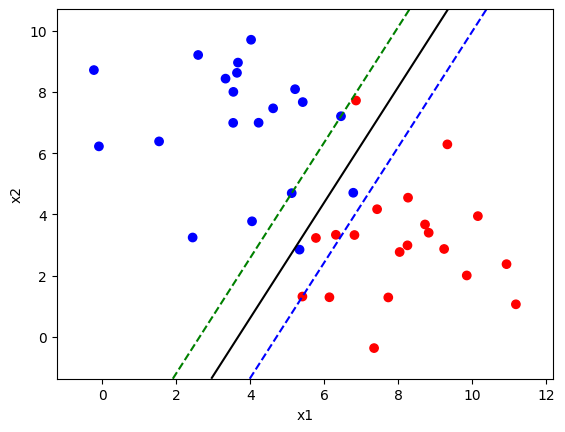

In [188]:
# ---- Your code here ----
plt.scatter(X[:, 0], X[:, 1], c=['red' if label == -1 else 'blue' for label in y])
x1_min, x1_max = X[:, 0].min()-1, X[:, 0].max()+1
x2_min, x2_max = X[:, 1].min()-1, X[:, 1].max()+1
range_X1 = np.linspace(x1_min, x1_max, 100)
range_X2 = np.linspace(x2_min, x2_max, 100)
decision = omega[0] * range_X1.reshape(-1, 1) + omega[1] * range_X2.reshape(1, -1) + b
boundary1 = omega[0] * range_X1.reshape(-1, 1) + omega[1] * range_X2.reshape(1, -1) + b - 1
boundary2 = omega[0] * range_X1.reshape(-1, 1) + omega[1] * range_X2.reshape(1, -1) + b + 1
plt.contour(range_X1, range_X2, boundary1.T, levels=[0], colors='green', linestyles='dashed')
plt.contour(range_X1, range_X2, boundary2.T, levels=[0], colors='blue', linestyles='dashed')
plt.contour(range_X1, range_X2, decision.T, levels=[0], colors='black')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

3.非线性支持向量机与核函数

[Raisin Dataset](https://www.kaggle.com/datasets/muratkokludataset/raisin-dataset)是一个葡萄干的数据集，总共有900个样本，每个样本包含7个(都是连续的)特征以及1个标签，每个标签只有两种可能取值。本次实验已经按照8：2的比例划分成了训练数据集'Raisin_train.csv'以及测试数据集'Raisin_test.csv'，且每个数据集都已经做了特征归一化处理以及把标签的值替换成了+1和-1。


<span style="color:purple">1) 读入训练数据集'Raisin_train.csv',把数据类型都转换成np.double类型。</span>

In [189]:
# ---- Your code here ----
file = pd.read_csv("Raisin_train.csv")
df = pd.DataFrame(file)
data = np.array(df, dtype=np.double)
X = data[:, :-1]
y = data[:, -1]

<span style="color:purple">2) 选择一个核函数$K(\pmb{x},\pmb{z})$以及参数C，求解如下对偶问题（参考课件）：</span>
$$
\begin{align}
\min_\alpha\quad   &\frac{1}{2}\sum_{i=1}^m\sum_{j=1}^m\alpha_i\alpha_jy_iy_jK(\pmb{x}_i,\pmb{x}_j)-\sum_{i=1}^m\alpha_i \\
s.t. \quad  &\sum_{i=1}^m\alpha_iy_i=0 \\
      &\pmb{0}\leq \pmb{\alpha}\leq C 
\end{align}
$$

相较于软间隔最大化的优化问题，该优化问题仅需要对矩阵$P$做改动。
从以下常用的核函数中选择一个作为该优化问题中的$K$（参数自己进行调整）：
* 线性核：$K(\pmb{x},\pmb{z})=\pmb{x}^T\pmb{z}$
* 多项式核：$K(\pmb{x},\pmb{z})=(\pmb{x}^T\pmb{z}+1)^p$
* 高斯核：$K(\pmb{x},\pmb{z})=exp(-\frac{\parallel \pmb{x}-\pmb{z} \parallel^2}{2\sigma^2})$
* 拉普拉斯核：$K(\pmb{x},\pmb{z})=exp(-\frac{\parallel \pmb{x}-\pmb{z} \parallel}{\sigma})$
* Sigmoid核：$K(\pmb{x},\pmb{z})=tanh(\beta\pmb{x}^T\pmb{z}+\theta)$

则$P是一个m\times m的矩阵，其中P_{ij}=y_iy_jK(\pmb{x_i},\pmb{x_j})$。

In [ ]:
# ---- Your code here ----
def gaussian_kernal(x, z, sigma=1.0):
    # return np.exp(-(x - z) ** 2 / (2 * sigma ** 2))
    x_diff = x[None, :, :] - z[:, None, :]
    x_diff = np.sum(x_diff, axis = -1)
    return np.exp(- (x_diff ** 2) / (2 * sigma ** 2))

def linear_kernal(x, z):
    x = x[None, :, :]
    z = z[:, None, :]
    result = x.T * z
    return result.sum(axis=-1)

kernal = gaussian_kernal
C = 1
P = (y.reshape(-1, 1) @ y.reshape(1, -1)) * kernal(X, X)
q = -np.ones(len(y))
A = y.reshape(1, -1)
b = np.array([0.0])
G = np.vstack((-np.eye(len(y)), np.eye(len(y))))
h = np.hstack((np.zeros(len(y)), C * np.ones(len(y)).T))
sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h), matrix(A), matrix(b))
alphas = np.array(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -3.5815e+02 -1.8172e+03  9e+03  3e+00  1e-14
 1: -2.3762e+02 -1.1750e+03  1e+03  2e-01  1e-14
 2: -2.5121e+02 -3.8712e+02  1e+02  2e-02  8e-15
 3: -2.7994e+02 -3.2903e+02  5e+01  5e-03  9e-15
 4: -2.8641e+02 -3.2075e+02  4e+01  2e-03  8e-15
 5: -2.9208e+02 -3.0998e+02  2e+01  9e-04  9e-15
 6: -2.9485e+02 -3.0527e+02  1e+01  4e-04  9e-15
 7: -2.9636e+02 -3.0286e+02  7e+00  2e-04  9e-15
 8: -2.9741e+02 -3.0119e+02  4e+00  1e-04  1e-14
 9: -2.9808e+02 -3.0013e+02  2e+00  5e-05  1e-14
10: -2.9876e+02 -2.9917e+02  4e-01  2e-14  1e-14
11: -2.9889e+02 -2.9902e+02  1e-01  2e-14  1e-14
12: -2.9894e+02 -2.9897e+02  3e-02  1e-14  1e-14
13: -2.9895e+02 -2.9896e+02  3e-03  2e-14  1e-14
14: -2.9895e+02 -2.9895e+02  4e-04  3e-14  1e-14
15: -2.9895e+02 -2.9895e+02  8e-06  7e-15  1e-14
Optimal solution found.


3) 求出$b^*=y_j-\sum_{i=1}^m \alpha_i^*y_iK(\pmb{x_i},\pmb{x_j})$, 其中$j$为$\alpha^*$中的一个正分量$0<\alpha_j^*<C$的下标。

In [191]:
# ---- Your code here ----
for i in range(len(alphas)):
    if alphas[i] > 1e-5:
        j = i
b = y[j] - np.sum(alphas.reshape(-1, 1) * y.reshape(-1, 1) * kernal(X, X[j].reshape(1, -1)).T, axis=0)
b.shape

(1,)

<span style="color:purple">4) 读入测试数据集'Raisin_test.csv',用分类决策函数$f(\pmb{x})=sign(\sum_{i=1}^m \alpha_i^*y_iK(\pmb{x}_i,\pmb{x})+b^*)$（注意这里的$m,\alpha_i^*,y_i,\pmb{x}_i$是训练集的, $\pmb{x}$是测试集的）进行预测，输出预测准确率。</span>

In [192]:
# ---- Your code here ----
file = pd.read_csv('Raisin_test.csv')
df = pd.DataFrame(file)
data = np.array(df, dtype=np.double)
Xtest = data[:, :-1]
ytest = data[:, -1]
fx = np.sign((alphas.reshape(-1, 1) * y.reshape(-1, 1)).T @ kernal(Xtest, X) + b)
accuracy = np.mean(ytest == fx)
# Xtest.shape, ytest.shape, alphas.shape
accuracy

np.float64(0.8444444444444444)